
# 01. 언어 부품의 사전지식과 순서대로 키우기

규칙 세계 v1, 처음 보는 조합(composition) 분할, seed 42. 결과 파일을 읽어서 그리기만 한다.

두 가지 질문을 다룬다.
1. **사전지식 대조**: "메시지 내용이 최종 답만으로 생긴다"는 결과는, 언어 부품이 이미 NLI(뒷받침/반박/무관)를 배운 모델이라서 나온 것인가?
2. **순서대로 키우기**: 읽기(언어 부품)와 판단(출처 구조 판단기)을 처음부터 같이 학습하면 멈춘다. 읽기를 먼저 배우고 판단을 나중에 배우면 되는가?

> 아직 seed 1개 결과다. 결론이 아니라 방향을 보는 그림이다.


In [1]:

import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()



## 1. 언어 부품이 NLI를 미리 배웠는가에 따라

| 이름 | 무엇인가 |
|---|---|
| NLI 모델 | mDeBERTa-v3, MNLI+XNLI로 미세조정됨 (지금까지 쓴 것) |
| 원본 모델 | 같은 mDeBERTa-v3, NLI 학습 전 (토크나이저 동일) |
| e5-small | 다른 작은 모델(1.2억), 영어 NLI 데이터를 약간 봄 |

판단기는 단순한 열쇠 대칭 판단기이고, 모두 최종 답만으로 학습했다. 오른쪽 탐침은 메시지에서 사람이 설계한 3분류를 얼마나 읽어낼 수 있는지다. 점선은 찍기 수준(0.74)이다.


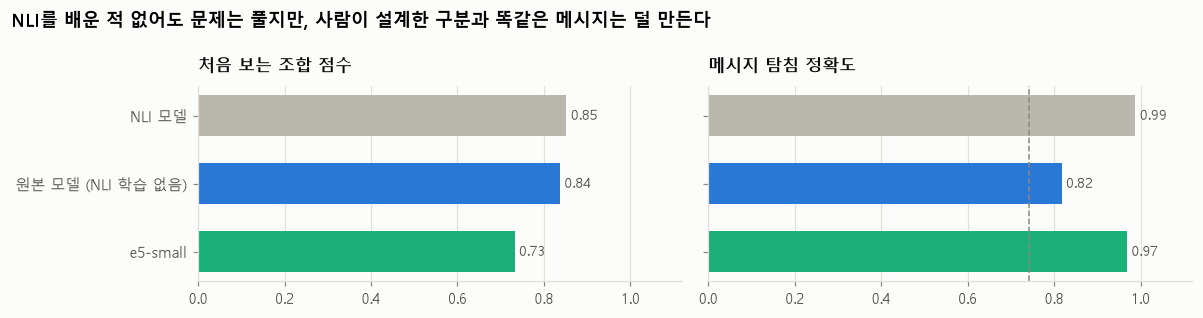

In [2]:

runs = [("NLI 모델", "interface-anchored-learned", V.NEUTRAL),
        ("원본 모델 (NLI 학습 없음)", "interface-anchored-learned-enc-base", V.BLUE),
        ("e5-small", "interface-anchored-learned-enc-e5", V.AQUA)]
data = [(label, S.interface_result(stem), color) for label, stem, color in runs]
data = [(label, d, color) for label, d, color in data if d]

fig, axes = plt.subplots(1, 2, figsize=(11, 2.9), sharey=True)
for ax, field, title in zip(axes, ("score", "probe"), ("처음 보는 조합 점수", "메시지 탐침 정확도")):
    for i, (label, d, color) in enumerate(data):
        ax.barh(i, d[field], height=0.6, color=color)
        ax.text(d[field] + 0.01, i, f"{d[field]:.2f}", va="center", fontsize=9, color=V.TEXT_SECONDARY)
    ax.set_xlim(0, 1.12)
    ax.grid(axis="y", visible=False)
    ax.set_title(title, fontsize=11, pad=10)
axes[1].axvline(0.742, color=V.MUTED, linestyle="--", linewidth=1)
axes[0].set_yticks(range(len(data)), [label for label, _, _ in data])
axes[0].invert_yaxis()
fig.suptitle("NLI를 배운 적 없어도 문제는 풀지만, 사람이 설계한 구분과 똑같은 메시지는 덜 만든다",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



**읽는 법**
- 점수: 원본 모델 0.84 ≈ NLI 모델 0.85. **최종 답만으로 학습되는 것 자체는 NLI 사전학습 없이도 된다.**
- 탐침: 원본 모델 0.82 < NLI 모델 0.99. **메시지가 사람의 설계와 똑같아지는 건 NLI 사전학습 덕이 컸다.** 원본 모델은 문제를 풀지만 메시지를 사람과 다른 방식으로 구성한다.
- 원본 모델은 6에폭째에 학습이 갑자기 무너졌다(아래 그림 3 참고). 검증 점수로 그 전의 모델을 골라서 결과에는 영향이 없지만, 불안정하다는 신호다.



## 2. 처음부터 같이 배우기 vs 순서대로 키우기

- **같이 배우기**: 언어 부품과 판단기를 처음부터 함께, 최종 답만으로 학습한다.
- **순서대로**: (1) 단순 판단기와 함께 읽기를 먼저 배운다 → (2) 그 언어 부품을 고정하고 출처 구조 판단기만 새로 학습한다.

출처 구조 판단기는 설계된 메시지를 받으면 seed 4개 모두 만점이었던 판단기다.


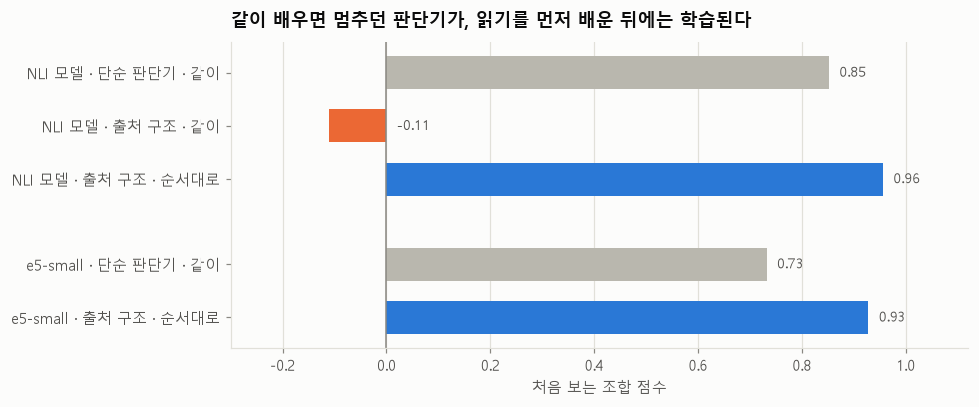

In [3]:

groups = [
    ("NLI 모델", [("단순 판단기 · 같이", "interface-anchored-learned", V.NEUTRAL),
                 ("출처 구조 · 같이", "interface-anchored-learned-sourcefold", V.ORANGE),
                 ("출처 구조 · 순서대로", "interface-anchored-learned-sourcefold-staged-frozen", V.BLUE)]),
    ("e5-small", [("단순 판단기 · 같이", "interface-anchored-learned-enc-e5", V.NEUTRAL),
                  ("출처 구조 · 순서대로", "interface-anchored-learned-sourcefold-enc-e5-staged-frozen", V.BLUE)]),
]
fig, ax = plt.subplots(figsize=(9, 3.8))
y, ticks, labels = 0, [], []
for reader, variants in groups:
    for label, stem, color in variants:
        d = S.interface_result(stem)
        if d is None:
            continue
        ax.barh(y, d["score"], height=0.62, color=color)
        x_text = max(d["score"], 0) + 0.02
        ax.text(x_text, y, f"{d['score']:.2f}", va="center", fontsize=9, color=V.TEXT_SECONDARY)
        ticks.append(y)
        labels.append(f"{reader} · {label}")
        y += 1
    y += 0.6
ax.axvline(0, color=V.MUTED, linewidth=1)
ax.set_yticks(ticks, labels)
ax.invert_yaxis()
ax.set_xlim(-0.3, 1.12)
ax.grid(axis="y", visible=False)
ax.set_xlabel("처음 보는 조합 점수")
ax.set_title("같이 배우면 멈추던 판단기가, 읽기를 먼저 배운 뒤에는 학습된다", pad=10)
fig.tight_layout()
plt.show()



## 3. 학습 과정: 무엇이 멈추고 무엇이 배우나 (검증 점수, 에폭별)


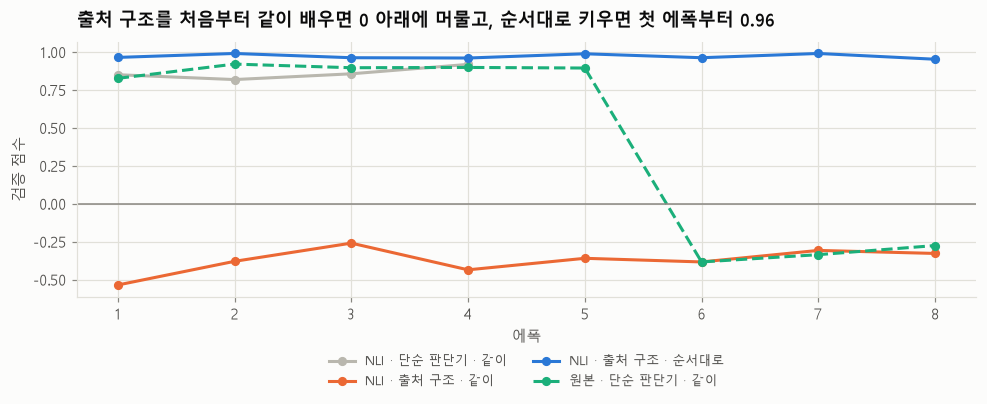

In [4]:

curves = [("NLI · 단순 판단기 · 같이", "interface-anchored-learned", V.NEUTRAL, "-"),
          ("NLI · 출처 구조 · 같이", "interface-anchored-learned-sourcefold", V.ORANGE, "-"),
          ("NLI · 출처 구조 · 순서대로", "interface-anchored-learned-sourcefold-staged-frozen", V.BLUE, "-"),
          ("원본 · 단순 판단기 · 같이", "interface-anchored-learned-enc-base", V.AQUA, "--")]
fig, ax = plt.subplots(figsize=(9, 3.9))
for label, stem, color, dash in curves:
    d = S.interface_result(stem)
    if d is None:
        continue
    epochs = range(1, len(d["validation"]) + 1)
    ax.plot(epochs, d["validation"], dash, color=color, marker="o", markersize=5, label=label)
ax.axhline(0, color=V.MUTED, linewidth=1)
ax.set_xlabel("에폭")
ax.set_ylabel("검증 점수")
ax.set_title("출처 구조를 처음부터 같이 배우면 0 아래에 머물고, 순서대로 키우면 첫 에폭부터 0.96", pad=10)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8.5)
fig.tight_layout()
plt.show()



## 4. 정리

1. **최종 답만으로 배우기**는 NLI 사전학습이 없어도 된다(점수 0.84). 하지만 메시지가 사람의 설계와 똑같아지는 건 사전학습의 영향이 컸다.
2. **복잡한 판단 구조는 처음부터 같이 배우면 멈춘다.** 메시지가 아무 정보도 담지 않은 채로 정답 비율만 외운다.
3. **읽기를 먼저 배우고 판단을 나중에 배우면 된다**(NLI 0.96, e5 0.93). "부품을 순서대로 키운다"는 발달 방식의 첫 긍정적 신호다. 어제 실패한 커리큘럼은 *문제의 난이도 순서*였고, 이번에는 *부품의 성장 순서*다.

**남은 확인**: seed 반복, 원본 모델로 순서대로 키우기, 2단계에서 언어 부품을 고정하지 않고 같이 미세조정하면 어떤지.
